# Per level analysis

Saved heatmaps-symmetric/level_level_2/heatmap_initiate_collaboration.png
Saved heatmaps-symmetric/level_level_2/heatmap_mean_f1_agent_0.png
Saved heatmaps-symmetric/level_level_2/heatmap_mean_f1_agent_1.png
Saved heatmaps-symmetric/level_level_2/heatmap_mean_redundancy_agent_0.png
Saved heatmaps-symmetric/level_level_2/heatmap_mean_redundancy_agent_1.png
Saved heatmaps-symmetric/level_level_2/heatmap_mean_similarity_agent_0.png
Saved heatmaps-symmetric/level_level_2/heatmap_mean_similarity_agent_1.png
Saved heatmaps-symmetric/level_level_2/heatmap_overall_collaboration.png
Saved heatmaps-symmetric/level_level_2/heatmap_respond_collaboration.png
Saved heatmaps-symmetric/level_level_2/heatmap_std_f1_agent_0.png
Saved heatmaps-symmetric/level_level_2/heatmap_std_f1_agent_1.png
Saved heatmaps-symmetric/level_level_2/heatmap_std_redundancy_agent_0.png
Saved heatmaps-symmetric/level_level_2/heatmap_std_redundancy_agent_1.png
Saved heatmaps-symmetric/level_level_2/heatmap_std_similarity_agen

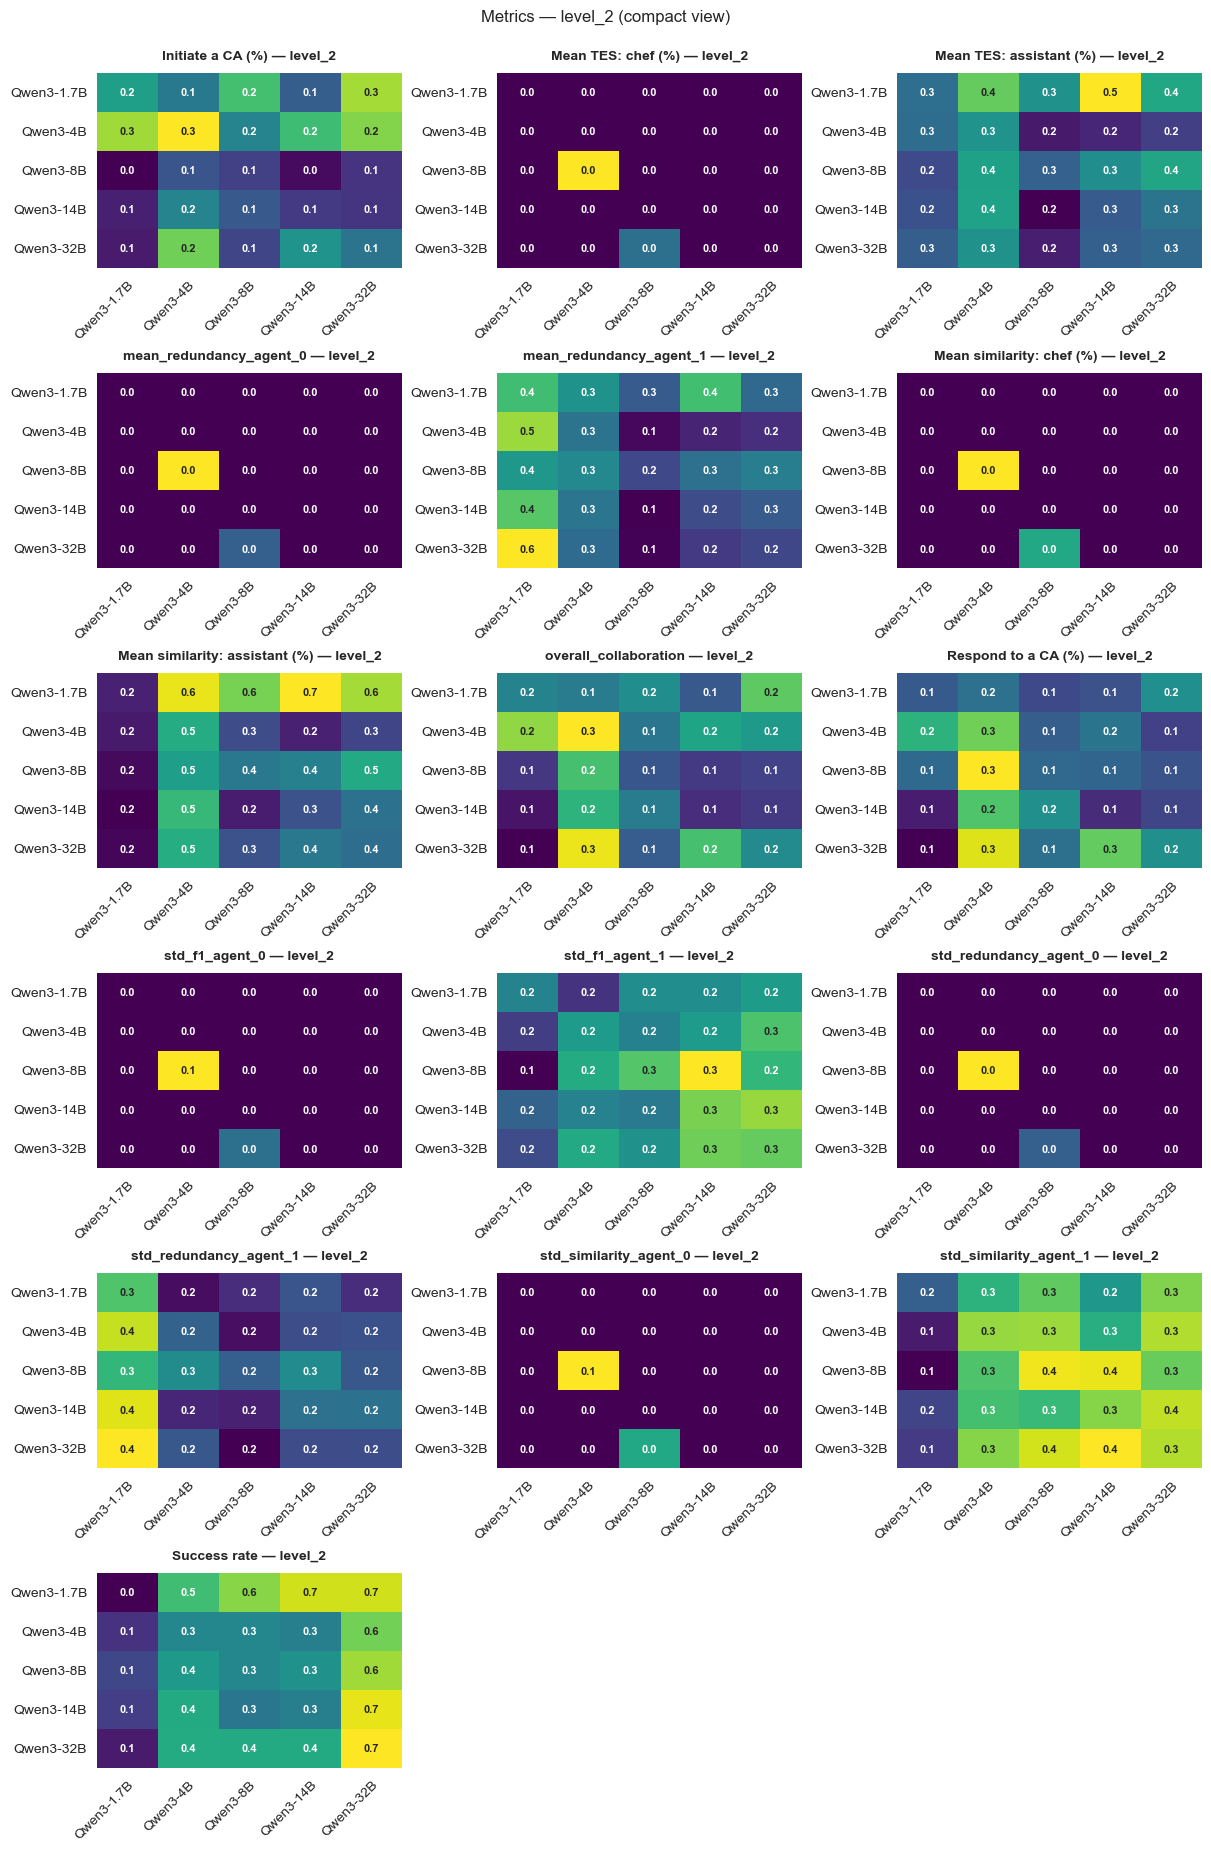

Saved heatmaps-symmetric/level_level_4/heatmap_initiate_collaboration.png
Saved heatmaps-symmetric/level_level_4/heatmap_mean_f1_agent_0.png
Saved heatmaps-symmetric/level_level_4/heatmap_mean_f1_agent_1.png
Saved heatmaps-symmetric/level_level_4/heatmap_mean_redundancy_agent_0.png
Saved heatmaps-symmetric/level_level_4/heatmap_mean_redundancy_agent_1.png
Saved heatmaps-symmetric/level_level_4/heatmap_mean_similarity_agent_0.png
Saved heatmaps-symmetric/level_level_4/heatmap_mean_similarity_agent_1.png
Saved heatmaps-symmetric/level_level_4/heatmap_overall_collaboration.png
Saved heatmaps-symmetric/level_level_4/heatmap_respond_collaboration.png
Saved heatmaps-symmetric/level_level_4/heatmap_std_f1_agent_0.png
Saved heatmaps-symmetric/level_level_4/heatmap_std_f1_agent_1.png
Saved heatmaps-symmetric/level_level_4/heatmap_std_redundancy_agent_0.png
Saved heatmaps-symmetric/level_level_4/heatmap_std_redundancy_agent_1.png
Saved heatmaps-symmetric/level_level_4/heatmap_std_similarity_agen

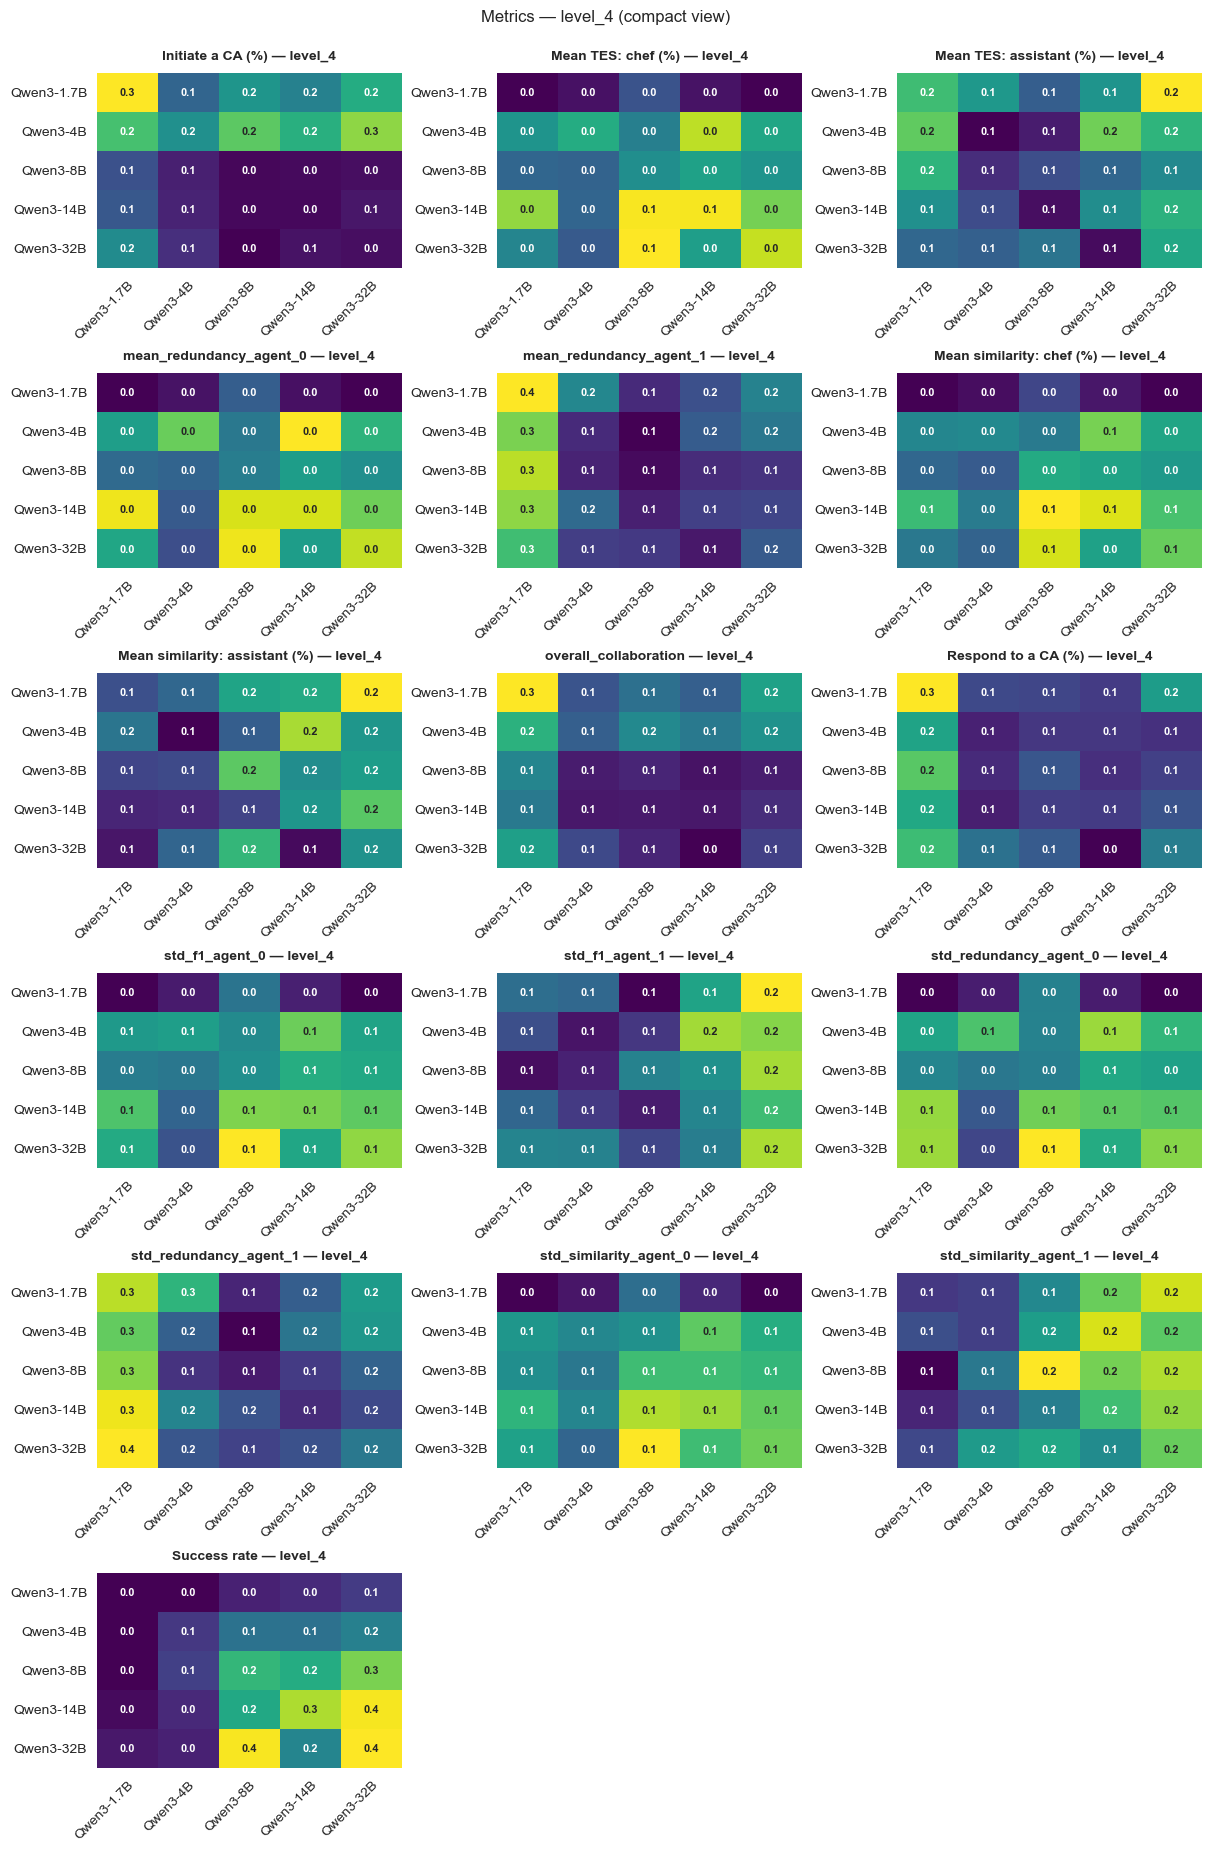

Saved heatmaps-symmetric/all_levels/heatmap_initiate_collaboration.png
Saved heatmaps-symmetric/all_levels/heatmap_mean_f1_agent_0.png
Saved heatmaps-symmetric/all_levels/heatmap_mean_f1_agent_1.png
Saved heatmaps-symmetric/all_levels/heatmap_mean_redundancy_agent_0.png
Saved heatmaps-symmetric/all_levels/heatmap_mean_redundancy_agent_1.png
Saved heatmaps-symmetric/all_levels/heatmap_mean_similarity_agent_0.png
Saved heatmaps-symmetric/all_levels/heatmap_mean_similarity_agent_1.png
Saved heatmaps-symmetric/all_levels/heatmap_overall_collaboration.png
Saved heatmaps-symmetric/all_levels/heatmap_respond_collaboration.png
Saved heatmaps-symmetric/all_levels/heatmap_std_f1_agent_0.png
Saved heatmaps-symmetric/all_levels/heatmap_std_f1_agent_1.png
Saved heatmaps-symmetric/all_levels/heatmap_std_redundancy_agent_0.png
Saved heatmaps-symmetric/all_levels/heatmap_std_redundancy_agent_1.png
Saved heatmaps-symmetric/all_levels/heatmap_std_similarity_agent_0.png
Saved heatmaps-symmetric/all_level

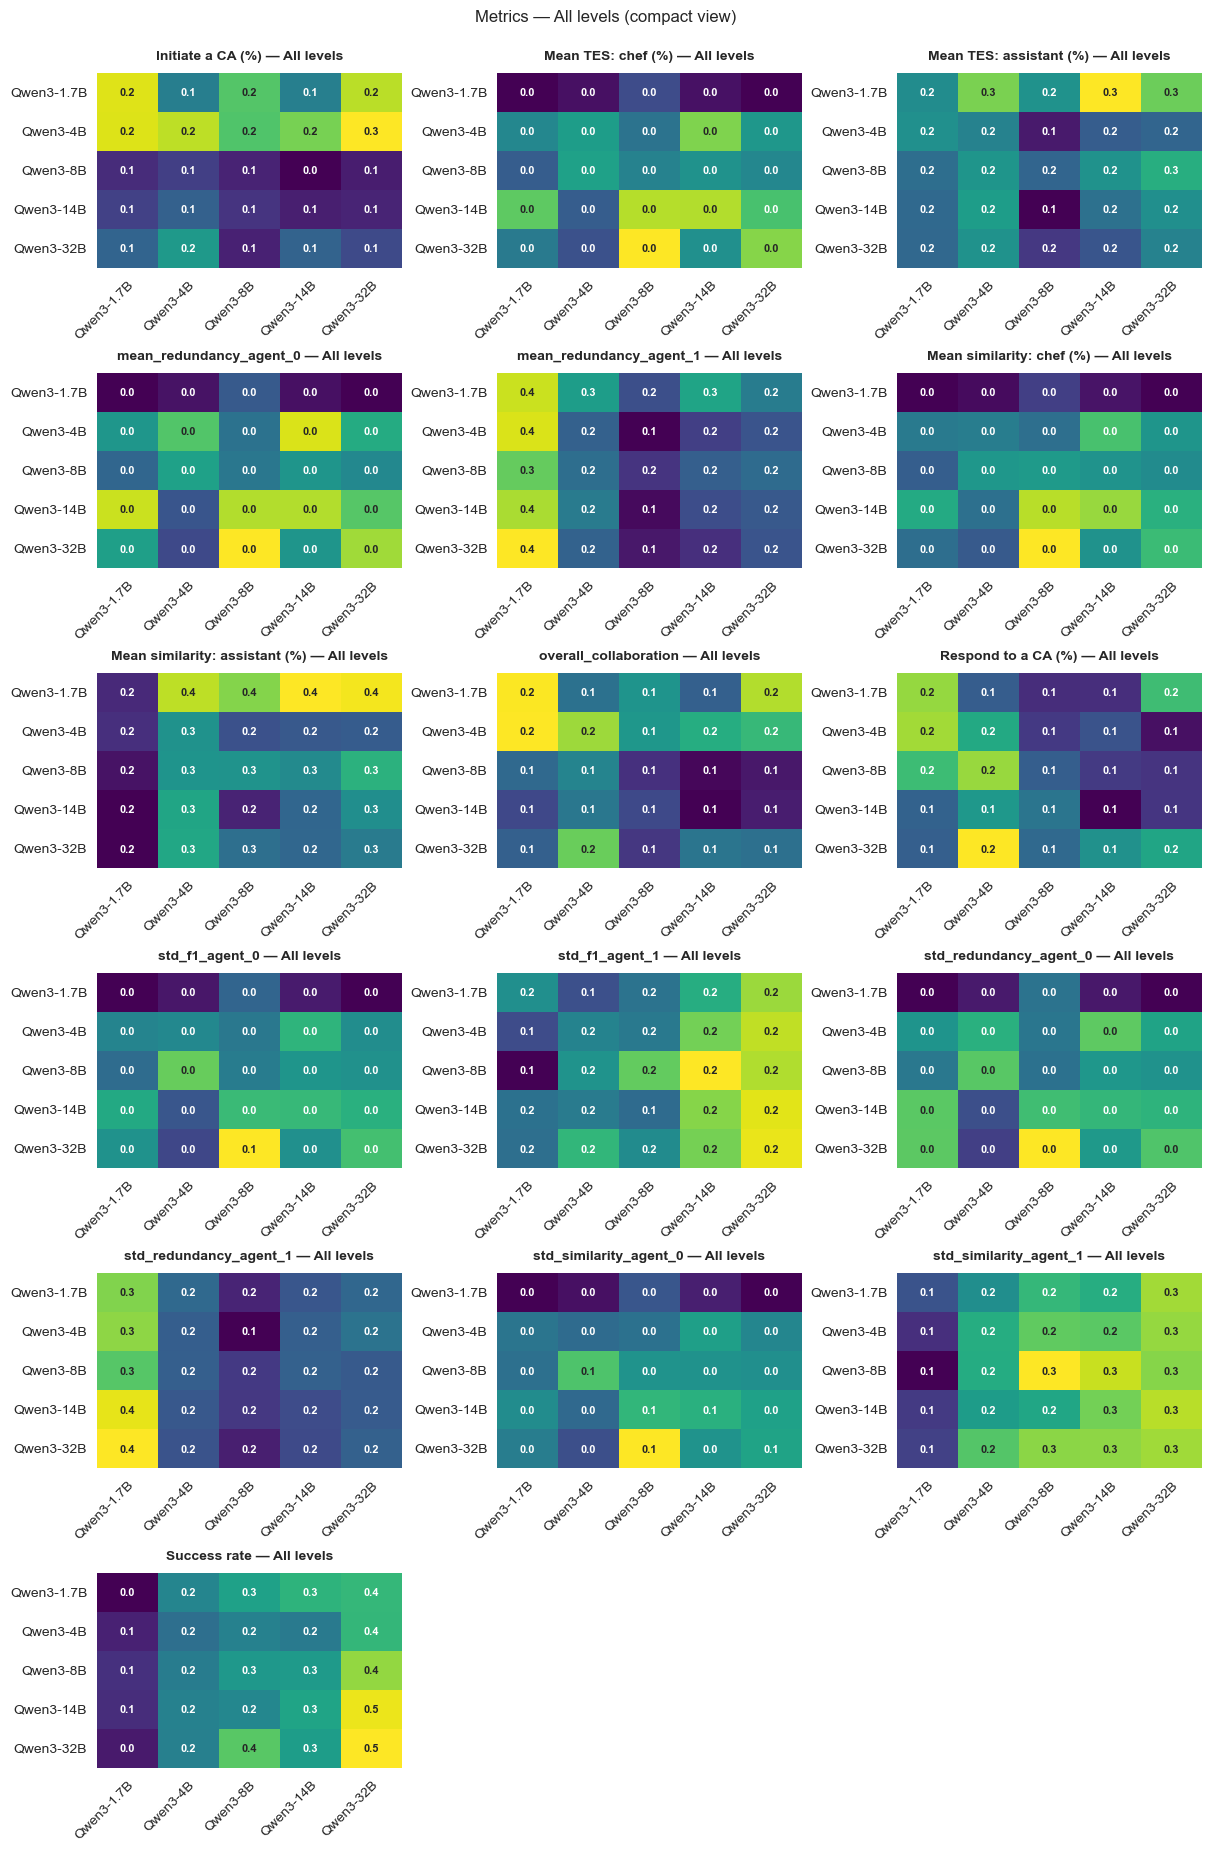

In [7]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Generate annotated heat-maps for every numeric metric in the input CSV.
Adds level-aware reporting:
  • Per-level heat-maps (each level separately)
  • Optional "all levels" aggregate, with configurable aggregation function
Saves PNGs and shows compact inline grids in a Jupyter notebook.

Updated: 2025-08-11 — level-aware aggregation
  • LEVEL_MODE: "each" | "all" | "each_and_all"
  • LEVELS_TO_INCLUDE: None (auto) or explicit list
  • Aggregation function for "all levels" is configurable (default: mean)
  • Folder structure: heatmaps/<level_slug>/...

Retains earlier changes (2025-07-09):
  • Centralised heat-map kwargs for PNG/inline parity
  • Suppressed colour-bars; compact 4×3 panels
  • Unicode U+2011 → ASCII "-" normalization to avoid glyph warnings
  • Identical titles for PNG and inline
"""

import math
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set a clean seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# ───────────────────────────────────────────────────────────────
# 0. User-configurable labels  (edit below as needed)
# ───────────────────────────────────────────────────────────────
# Pretty names for models that will appear on axes ticks.
# Keys must match raw entries found in agent0_model / agent1_model
model_labels: dict[str, str] = {
    "Qwen2.5-14B-Instruct": "Qwen2.5-14B",
    "Qwen2.5-32B-Instruct": "Qwen2.5-32B",
    "Qwen2.5-7B-Instruct" : "Qwen2.5-07B",
    "Mistral-7B-Instruct-v0.1": "Mistral-07B",
    "Meta-Llama-3-8B-Instruct": "Llama3-08B",
}

# Normalise dictionary keys (replace non-breaking hyphen with standard hyphen)
model_labels = {k.replace("\u2011", "-"): v for k, v in model_labels.items()}

# Pretty names for metric labels and colour-bar.
metric_labels: dict[str, str] = {
    "mean_similarity_agent_0": "Mean similarity: chef (%)",
    "mean_similarity_agent_1": "Mean similarity: assistant (%)",
    "mean_f1_agent_0": "Mean TES: chef (%)",
    "mean_f1_agent_1": "Mean TES: assistant (%)",
    "initiate_collaboration": "Initiate a CA (%)",
    "respond_collaboration": "Respond to a CA (%)",
    "success_rate": "Success rate",
}

# Optional: human-friendly names for levels, e.g. {0: "Easy", 1: "Med", 2: "Hard"}
level_labels: dict = {}  # leave empty to use the raw level values

# Axis labels (set to blank to mirror inline view)
x_axis_label: str = ""
y_axis_label: str = ""
# Title template mirrors inline/PNG parity.
# Use {metric_label} and {level_label} tokens; for "all levels" we inject "All levels".
title_template: str = "{metric_label} — {level_label}"

# ───────────────────────────────────────────────────────────────
# 0-bis. Centralised heat-map styling — **single source of truth**
# ───────────────────────────────────────────────────────────────
HEATMAP_KWARGS: dict = dict(
    annot=True,
    fmt=".1f",
    annot_kws={"size": 8, "weight": "bold"},  # slightly larger, bold text
    cmap="viridis",             # modern seaborn colormap
    linewidths=0.0,
    linecolor="white",
    cbar=False,                # suppress colour-bar as in notebook view
    square=False,               # make cells square for better proportions
)

# ───────────────────────────────────────────────────────────────
# 0-ter. Level reporting controls
# ───────────────────────────────────────────────────────────────
# Choose: "each" (per-level only), "all" (aggregate only), "each_and_all" (both)
LEVEL_MODE: str = "each_and_all"

# Explicit subset of levels to include, or None to auto-discover
LEVELS_TO_INCLUDE: Optional[Iterable] = None

# Aggregation function for "all levels"
AGG_FUN = "mean"  # "mean", "median", "max", "min", or any pandas reducer name

# Composite grid layout (inline)
N_COLS_COMPOSITE: int = 3

# ───────────────────────────────────────────────────────────────
# 1. Load and pre-process
# ───────────────────────────────────────────────────────────────
# IMPORTANT: point this to your uploaded CSV file
csv_path = "converted_data_symmetric_data.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Split the composite model column → agent0_model / agent1_model
# Assumes "model" looks like "..._<agent0>_VS_<agent1>_..."
parts = df["model"].str.split("_", expand=True)
df["agent0_model"] = parts[1]
df["agent1_model"] = parts[3]

# Replace any non-breaking hyphens (U+2011) with the standard hyphen-minus
for col in ("agent0_model", "agent1_model"):
    df[col] = df[col].str.replace("\u2011", "-", regex=False)

# Identify all numeric metrics (drop clearly non-metric timing columns)
numeric_cols = (
    df.select_dtypes(include="number")
      .columns.difference(["level", "steps", "time_avg", "time_var"])
      .tolist()
)

# Decide which levels we will include
if LEVELS_TO_INCLUDE is None:
    # Use the order of appearance (stable) for consistent panel ordering
    levels_in_data = list(pd.unique(df["level"]))
else:
    levels_in_data = list(LEVELS_TO_INCLUDE)

# Helper to pretty-print level values
def _level_name(val):
    if val == "__ALL__":
        return "All levels"
    return level_labels.get(val, str(val))

# ───────────────────────────────────────────────────────────────
# 2. Group once at the most granular level we care about
#    Mean over duplicate rows within (agent0, agent1, level)
# ───────────────────────────────────────────────────────────────
group_cols = ["agent0_model", "agent1_model", "level"]
df_mean = (
    df.groupby(group_cols, dropna=False)[numeric_cols]
      .mean()
      .reset_index()
)

# Build a list of "reporting scopes": each level, plus optionally an "__ALL__" aggregate
report_scopes = []
if LEVEL_MODE in ("each", "each_and_all"):
    report_scopes.extend(levels_in_data)
if LEVEL_MODE in ("all", "each_and_all"):
    report_scopes.append("__ALL__")

# ───────────────────────────────────────────────────────────────
# 3. Rendering utilities
# ───────────────────────────────────────────────────────────────

## All of the code in this block is meant to alphabetically sort models names ##
import re

# If you mix families (e.g., Qwen3, Llama3), set this True to sort "within family"
ORDER_WITHIN_FAMILY = True

_SCALE = {"K": 1e-3, "M": 1e-6, "B": 1.0, "T": 1e3}

def _size_sort_key(label: str):
    s = str(label)
    # Split once at the last '-' so "Qwen3-14B" → ("Qwen3", "14B")
    if "-" in s:
        family, tail = s.rsplit("-", 1)
    else:
        family, tail = s, s
    # Parse something like "14B", "1.7B", "07B"
    m = re.search(r"(\d+(?:\.\d+)?)[ ]*([KMBT])\b", tail, flags=re.I)
    if m:
        num = float(m.group(1))
        unit = m.group(2).upper()
        size_b = num * _SCALE.get(unit, 1.0)  # normalize to “billions”
    else:
        size_b = float("inf")  # unparseable labels go to the end

    if ORDER_WITHIN_FAMILY:
        return (family.casefold(), size_b, s.casefold())
    else:
        # Pure size ordering across all families
        return (size_b, family.casefold(), s.casefold())
## All of the code in this block is meant to alphabetically sort models names ##

def _pivot_for_scope(metric: str, scope):
    """
    Return a pivot (rows=agent0, cols=agent1) for a given metric and scope (level or "__ALL__").
    Applies model label prettification and sorts axes.
    """
    if scope == "__ALL__":
        # Aggregate across levels first
        agg = (
            df_mean.groupby(["agent0_model", "agent1_model"], dropna=False)[metric]
                  .agg(AGG_FUN)
                  .reset_index()
        )
    else:
        # Filter for the specific level
        agg = df_mean[df_mean["level"] == scope][["agent0_model", "agent1_model", metric]]

    pivot = (
        agg.groupby(["agent0_model", "agent1_model"])[metric]
           .mean()
           .unstack(fill_value=np.nan)
    )

    pivot = pivot.rename(index=model_labels, columns=model_labels)
    
    # Sort axes by numeric model size (then by family for ties if enabled)
    row_order = sorted(pivot.index, key=_size_sort_key)
    col_order = sorted(pivot.columns, key=_size_sort_key)
    pivot = pivot.reindex(index=row_order, columns=col_order)
    return pivot

def _save_and_collect(pivots_for_scope: dict, scope, out_root: Path):
    """
    Save individual PNGs for a scope to heatmaps/<level_slug>/..., and return a list of (metric_label, pivot).
    """
    level_slug = "all_levels" if scope == "__ALL__" else f"level_{_level_name(scope)}".replace(" ", "_")
    out_dir = out_root / level_slug
    out_dir.mkdir(parents=True, exist_ok=True)

    collected = []
    for metric in numeric_cols:
        pivot = _pivot_for_scope(metric, scope)
        metric_label = metric_labels.get(metric, metric)

        # Store for composite grid
        collected.append((metric_label, pivot))

        # Individual PNG with better seaborn styling
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(pivot, **HEATMAP_KWARGS, ax=ax)

        title = title_template.format(metric_label=metric_label, level_label=_level_name(scope))
        ax.set_title(title, pad=15, fontsize=12, fontweight='bold')
        ax.set_xlabel(x_axis_label, fontsize=10)
        ax.set_ylabel(y_axis_label, fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

        fig.tight_layout()
        outfile = out_dir / f"heatmap_{metric}.png"
        fig.savefig(outfile, dpi=300)
        plt.close(fig)
        print(f"Saved {outfile}")
    return collected, out_dir

def _composite_inline(collected: list, scope):
    """
    Show a compact inline grid for a given scope.
    """
    n = len(collected)
    if n == 0:
        return
    ncols = max(1, N_COLS_COMPOSITE)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4, nrows * 3),
        squeeze=False,
        constrained_layout=True,
    )

    for idx, (metric_label, pivot) in enumerate(collected):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sns.heatmap(pivot, **HEATMAP_KWARGS, ax=ax)
        # Inline titles with better styling
        inline_title = title_template.format(metric_label=metric_label, level_label=_level_name(scope))
        ax.set_title(inline_title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Hide any unused axes
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].axis("off")

    fig.suptitle(f"Metrics — {_level_name(scope)} (compact view)", y=1.02, fontsize=12)
    plt.show()

# ───────────────────────────────────────────────────────────────
# 4. Run: save PNGs and show inline grids for each requested scope
# ───────────────────────────────────────────────────────────────
out_root = Path("heatmaps-symmetric")
out_root.mkdir(exist_ok=True)

for scope in report_scopes:
    try:
        collected, scope_dir = _save_and_collect({}, scope, out_root)
        _composite_inline(collected, scope)
    except Exception as e:
        # Fail quietly outside interactive sessions, but print scope for debugging
        print(f"[WARN] Skipped inline view for scope={_level_name(scope)} due to: {e}")
